In [78]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.svm import SVR
import numpy as np
import joblib


# Load the cleaned dataset

df = pd.read_csv('../data/processed/cleaned_data.csv')

In [2]:
# Encode ordinal categorical variables
# The order Low < Medium < High is represented by 0 < 1 < 2.

level = {'Low': 0, 'Medium': 1, 'High': 2}
ordinal_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality']

for col in ordinal_cols:
    df[col] = df[col].map(level)

edu_mapping = {'High School': 0, 'College': 1, 'Postgraduate': 2}
df['Parental_Education_Level'] = df['Parental_Education_Level'].map(edu_mapping)

# One-hot encode the remaining categorical variables

df_encoded = pd.get_dummies(df, dtype=int, drop_first=True)

In [3]:
# Check the encoded dataset

df_encoded.head()
df_encoded.shape


(6607, 22)

In [4]:
# Separate features (X) from the target variable (y)

X = df_encoded.drop(columns=['Exam_Score'])
y = df_encoded['Exam_Score']
feature_cols = X.columns

In [5]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Standardize features using the training data

scale_standard = StandardScaler()
X_train_std = pd.DataFrame(scale_standard.fit_transform(X_train), columns=feature_cols)
X_test_std = pd.DataFrame(scale_standard.transform(X_test), columns=feature_cols)


In [7]:
# Normalize features to the range [0, 1]

scal_min_max = MinMaxScaler(feature_range=(0,1))
X_train_minmax = pd.DataFrame(scal_min_max.fit_transform(X_train), columns=feature_cols)
X_test_minmax = pd.DataFrame(scal_min_max.transform(X_test), columns=feature_cols)

In [34]:
# train the model using Standardized data

lr = LinearRegression()
lr.fit(X_train_std, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 1.76, 2.29, 0.7 ,..., 0.15, 0.42,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](21,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Distance_from_Home_Moderate','Distance_from_Home_Near','Gender_Male']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,67.21
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(21)


In [ ]:
y_pred_lr = lr.predict(X_test_std)
# len(y_pred_lr)

1322

In [35]:
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(mae)
print(mse)
print(r2)

0.447541101576228
3.247385744906821
0.7702604106843473


In [36]:
# Create a DataFrame comparing original vs y_pred

results = pd.DataFrame({
    'original': y_test.values,
    'y_pred': y_pred_lr
})

results['Difference'] = results['original'] - results['y_pred']
results = results.round(2)
results.head(20)

,original,y_pred,Difference
0,65,64.61,0.39
1,65,65.25,-0.25
2,71,71.52,-0.52
3,64,64.24,-0.24
4,66,66.46,-0.46
5,66,66.61,-0.61
6,72,72.45,-0.45
7,66,66.41,-0.41
8,70,69.93,0.07
9,70,70.08,-0.08


In [37]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_pipeline = make_pipeline(StandardScaler(), LinearRegression())

In [40]:
cv_scores = cross_val_score(cv_pipeline, X, y, cv=kfold, scoring='r2')

print(cv_scores)
print(cv_scores.mean())


[0.77026041 0.74680013 0.89725192 0.68480529 0.58936888]
0.7376973273944996


In [41]:
svr = SVR()
svr.fit(X_train_std, y_train)
y_pred_svr = svr.predict(X_test_std)

In [42]:
# Evaluate SVR

svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_mse = mean_squared_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, y_pred_svr)

print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2:", svr_r2)

MAE: 0.5549233550345325
RMSE: 1.8540589192440387
R2: 0.7568081463621081


In [16]:
# Random Forest

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 1.0806959152798787
RMSE: 2.1576894825662483
R2: 0.6706331777179395


In [18]:
lr_param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr_grid = GridSearchCV(
    LinearRegression(),
    lr_param_grid,
    cv=3,
    scoring='r2'
)

lr_grid.fit(X_train_std, y_train)

print(lr_grid.best_params_)
print(lr_grid.best_score_)

{'fit_intercept': True, 'positive': False}
0.7188947742085084


In [19]:
lr_best = lr_grid.best_estimator_

y_pred_lr_tuned = lr_best.predict(X_test_std)


In [20]:
lr_tuned_mae = mean_absolute_error(y_test, y_pred_lr_tuned)
lr_tuned_mse = mean_squared_error(y_test, y_pred_lr_tuned)
lr_tuned_rmse = np.sqrt(lr_tuned_mse)
lr_tuned_r2 = r2_score(y_test, y_pred_lr_tuned)

print("MAE:", lr_tuned_mae)
print("RMSE:", lr_tuned_rmse)
print("R2:", lr_tuned_r2)

MAE: 0.447541101576228
RMSE: 1.8020504279588907
R2: 0.7702604106843473


In [21]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [22]:
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='r2'
)

In [43]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Cont

In [44]:
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
0.6251388032447971


In [45]:
rf_best = rf_grid.best_estimator_

In [46]:
y_pred_rf_tuned = rf_best.predict(X_test)

In [47]:
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_mse = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

print("MAE:", rf_tuned_mae)
print("RMSE:", rf_tuned_rmse)
print("R2:", rf_tuned_r2)

MAE: 1.0738505041966875
RMSE: 2.1342114432919916
R2: 0.6777619291757475


In [49]:
svr_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'epsilon': [0.01, 0.1, 1]
}

svr_grid = GridSearchCV(
    SVR(),
    svr_param_grid,
    cv=3,
    scoring='r2'
)

svr_grid.fit(X_train_std, y_train)

y_pred_rf_tuned = rf_best.predict(X_test)

print(svr_grid.best_params_)
print(svr_grid.best_score_)

{'C': 0.1, 'epsilon': 1, 'kernel': 'linear'}
0.7190472240831204


In [50]:
svr_best = svr_grid.best_estimator_

y_pred_svr_tuned = svr_best.predict(X_test_std)

svr_tuned_mae = mean_absolute_error(y_test, y_pred_svr_tuned)
svr_tuned_mse = mean_squared_error(y_test, y_pred_svr_tuned)
svr_tuned_rmse = np.sqrt(svr_tuned_mse)
svr_tuned_r2 = r2_score(y_test, y_pred_svr_tuned)

print("MAE:", svr_tuned_mae)
print("RMSE:", svr_tuned_rmse)
print("R2:", svr_tuned_r2)

MAE: 0.4913934457598277
RMSE: 1.80163030625331
R2: 0.7703675190489708


In [56]:
lr_residuals = y_test - y_pred_lr_tuned
rf_residuals = y_test - y_pred_rf_tuned
svr_residuals = y_test - y_pred_svr_tuned

In [70]:
lr_residual_std = np.std(lr_residuals)
rf_residual_std = np.std(rf_residuals)
svr_residual_std = np.std(svr_residuals)

print("Linear Regression:", lr_residual_std)
print("Random Forest:", rf_residual_std)
print("SVR:", svr_residual_std)


Linear Regression: 1.801386095942884
Random Forest: 2.13195440069972
SVR: 1.794373635824171


Text(0.5, 0, 'Residual')

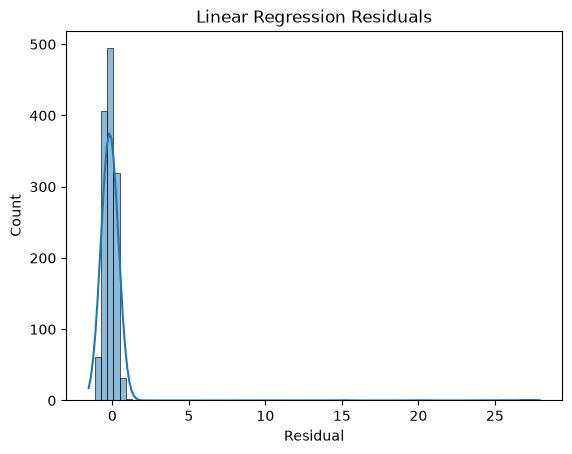

In [71]:
sns.histplot(lr_residuals, kde=True)
plt.title('Linear Regression Residuals')
plt.xlabel('Residual')

Text(0.5, 0, 'Residual')

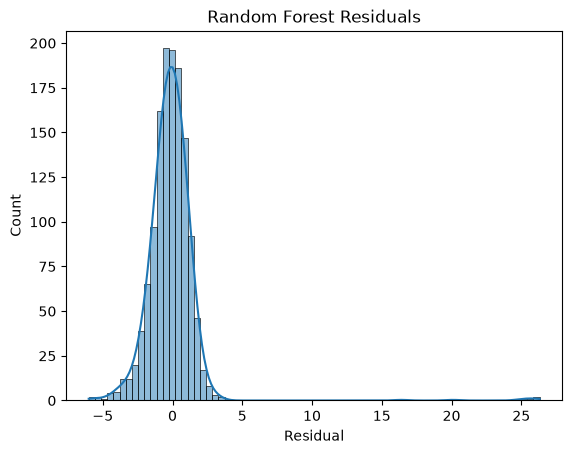

In [72]:
sns.histplot(rf_residuals, kde=True)
plt.title('Random Forest Residuals')
plt.xlabel('Residual')

Text(0.5, 0, 'Residual')

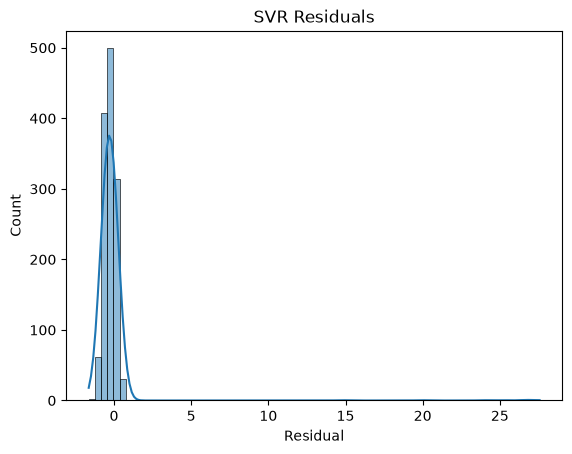

In [73]:
sns.histplot(svr_residuals, kde=True)
plt.title('SVR Residuals')
plt.xlabel('Residual')

In [74]:
lr_cv_r2_std = lr_grid.cv_results_['std_test_score'][lr_grid.best_index_]
rf_cv_r2_std = rf_grid.cv_results_['std_test_score'][rf_grid.best_index_]
svr_cv_r2_std = svr_grid.cv_results_['std_test_score'][svr_grid.best_index_]

print("Linear Regression:", lr_cv_r2_std)
print("Random Forest:", rf_cv_r2_std)
print("SVR:", svr_cv_r2_std)

Linear Regression: 0.05574714231004443
Random Forest: 0.050710452820626244
SVR: 0.05629293283097541


In [75]:
final_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'SVR'
    ],
    'RMSE': [
        lr_tuned_rmse,
        rf_tuned_rmse,
        svr_tuned_rmse
    ],
    'MAE': [
        lr_tuned_mae,
        rf_tuned_mae,
        svr_tuned_mae
    ],
    'R2': [
        lr_tuned_r2,
        rf_tuned_r2,
        svr_tuned_r2
    ],
    'Residual Std': [
        lr_residual_std,
        rf_residual_std,
        svr_residual_std
    ],
    'CV R2 Std': [
        lr_cv_r2_std,
        rf_cv_r2_std,
        svr_cv_r2_std
    ]
})

final_results

,Model,RMSE,MAE,R2,Residual Std,CV R2 Std
0,Linear Regression,1.802050,0.447541,0.770260,1.801386,0.055747
1,Random Forest,2.134211,1.073851,0.677762,2.131954,0.050710
2,SVR,1.801630,0.491393,0.770368,1.794374,0.056293


In [76]:
final_pipeline = make_pipeline(
    StandardScaler(),
    SVR(
        C=svr_best.C,
        kernel=svr_best.kernel,
        epsilon=svr_best.epsilon
    )
)

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Distance_from_Home_Moderate','Distance_from_Home_Near','Gender_Male']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [81]:
joblib.dump(
    {
        'model': final_pipeline,
        'feature_columns': list(feature_cols)
    },
    '../models/final_model.joblib'
)

['../models/final_model.joblib']